# Exploración inicial de datos Sentinel-2

## Trabajo de Fin de Grado
**Proyecto:** Sistema Inteligente de Recomendación de Riego para el Cultivo de Patata

## Objetivo
Analizar el archivo CSV generado mediante Google Earth Engine a partir de
imágenes Sentinel-2 de la parcela de estudio.

En esta primera fase se comprobarán:
- La estructura del conjunto de datos.
- Las columnas disponibles.
- El intervalo temporal.
- Los valores ausentes.
- La evolución de varios índices espectrales.
- La calidad de las observaciones mediante NDVI_count.

## Fuente de datos
Los archivos fueron generados mediante Google Earth Engine y almacenados en
Google Drive en la carpeta:

`/content/drive/MyDrive/Sentinel2_Indices/`

El archivo principal utilizado en este análisis es:

`maiz_sentinel2_indices_abril_septiembre_2018.csv`

## Nota metodológica
Los índices Sentinel-2 describen características espectrales de la vegetación, pero no miden directamente la humedad del suelo. Por tanto, se utilizarán como variables auxiliares del futuro simulador y deberán complementarse con datos
meteorológicos y un modelo de balance hídrico.

In [ ]:
# Librerías principales
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# Mostrar más columnas y filas en los resultados
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")
print("Conexión con Drive exitosa.")

Mounted at /content/drive
Conexión con Drive exitosa.


## Carga del conjunto de datos

El CSV se leerá desde Google Drive. Se convierte la columna **date** directamente
a formato de fecha para poder ordenar y
analizar temporalmente las observaciones.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

drive_path = "/content/drive/MyDrive/Sentinel2_Indices"

print("¿Existe la carpeta?")
print(os.path.exists(drive_path))

¿Existe la carpeta?
True


In [ ]:
files_in_folder = os.listdir(drive_path)

print("Archivos encontrados:")
for file in files_in_folder:
    print(file)

Archivos encontrados:
maiz_sentinel2_indices_abril_septiembre_2018.csv
maiz_NDVI_abril_septiembre_2018.csv
maiz_NDMI_abril_septiembre_2018.csv
maiz_GNDVI_abril_septiembre_2018.csv
maiz_NDRE3_abril_septiembre_2018.csv
maiz_NDRE_abril_septiembre_2018.csv
maiz_MNDWI_abril_septiembre_2018.csv
maiz_NDRE2_abril_septiembre_2018.csv
maiz_NBR_abril_septiembre_2018.csv
maiz_NDWI_abril_septiembre_2018.csv
maiz_BSI_abril_septiembre_2018.csv
maiz_NIR_RED_abril_septiembre_2018.csv
maiz_EVI_abril_septiembre_2018.csv
maiz_RECI_abril_septiembre_2018.csv
maiz_MSI_abril_septiembre_2018.csv
maiz_SAVI_abril_septiembre_2018.csv


In [ ]:
csv_path = (
    "/content/drive/MyDrive/"
    "Sentinel2_Indices/"
    "maiz_sentinel2_indices_abril_septiembre_2018.csv"
)

print("Ruta del CSV:")
print(csv_path)

print("\n¿Existe el CSV?")
print(os.path.exists(csv_path))

Ruta del CSV:
/content/drive/MyDrive/Sentinel2_Indices/maiz_sentinel2_indices_abril_septiembre_2018.csv

¿Existe el CSV?
True


In [ ]:
import pandas as pd

df = pd.read_csv(
    csv_path,
    parse_dates=["date"]
)

print("Archivo cargado correctamente.")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Archivo cargado correctamente.
Filas: 60
Columnas: 123


In [ ]:
print("Columnas disponibles:\n")

for number, column in enumerate(
    df.columns,
    start=1
):
    print(f"{number:02d}. {column}")

mean_columns = [
    column
    for column in df.columns
    if column.endswith("_mean")
]

print("\nColumnas de medias:")
print(mean_columns)

df = df.sort_values(
    "date"
).reset_index(drop=True)

print("Primera fecha:", df["date"].min())
print("Última fecha:", df["date"].max())
print(
    "Número de fechas distintas:",
    df["date"].nunique()
)

Columnas disponibles:

01. BSI_count
02. BSI_max
03. BSI_mean
04. BSI_median
05. BSI_min
06. BSI_p25
07. BSI_p75
08. BSI_std
09. EVI_count
10. EVI_max
11. EVI_mean
12. EVI_median
13. EVI_min
14. EVI_p25
15. EVI_p75
16. EVI_std
17. GNDVI_count
18. GNDVI_max
19. GNDVI_mean
20. GNDVI_median
21. GNDVI_min
22. GNDVI_p25
23. GNDVI_p75
24. GNDVI_std
25. MNDWI_count
26. MNDWI_max
27. MNDWI_mean
28. MNDWI_median
29. MNDWI_min
30. MNDWI_p25
31. MNDWI_p75
32. MNDWI_std
33. MSI_count
34. MSI_max
35. MSI_mean
36. MSI_median
37. MSI_min
38. MSI_p25
39. MSI_p75
40. MSI_std
41. NBR_count
42. NBR_max
43. NBR_mean
44. NBR_median
45. NBR_min
46. NBR_p25
47. NBR_p75
48. NBR_std
49. NDMI_count
50. NDMI_max
51. NDMI_mean
52. NDMI_median
53. NDMI_min
54. NDMI_p25
55. NDMI_p75
56. NDMI_std
57. NDRE2_count
58. NDRE2_max
59. NDRE2_mean
60. NDRE2_median
61. NDRE2_min
62. NDRE2_p25
63. NDRE2_p75
64. NDRE2_std
65. NDRE3_count
66. NDRE3_max
67. NDRE3_mean
68. NDRE3_median
69. NDRE3_min
70. NDRE3_p25
71. NDRE3_p75
7

In [ ]:
print(os.path.exists(csv_path))
df.head()

True


,BSI_count,BSI_max,BSI_mean,BSI_median,BSI_min,BSI_p25,BSI_p75,BSI_std,EVI_count,EVI_max,EVI_mean,EVI_median,EVI_min,EVI_p25,EVI_p75,EVI_std,GNDVI_count,GNDVI_max,GNDVI_mean,GNDVI_median,GNDVI_min,GNDVI_p25,GNDVI_p75,GNDVI_std,MNDWI_count,MNDWI_max,MNDWI_mean,MNDWI_median,MNDWI_min,MNDWI_p25,MNDWI_p75,MNDWI_std,MSI_count,MSI_max,MSI_mean,MSI_median,MSI_min,MSI_p25,MSI_p75,MSI_std,NBR_count,NBR_max,NBR_mean,NBR_median,NBR_min,NBR_p25,NBR_p75,NBR_std,NDMI_count,NDMI_max,...,NDRE_max,NDRE_mean,NDRE_median,NDRE_min,NDRE_p25,NDRE_p75,NDRE_std,NDVI_count,NDVI_max,NDVI_mean,NDVI_median,NDVI_min,NDVI_p25,NDVI_p75,NDVI_std,NDWI_count,NDWI_max,NDWI_mean,NDWI_median,NDWI_min,NDWI_p25,NDWI_p75,NDWI_std,NIR_RED_count,NIR_RED_max,NIR_RED_mean,NIR_RED_median,NIR_RED_min,NIR_RED_p25,NIR_RED_p75,NIR_RED_std,RECI_count,RECI_max,RECI_mean,RECI_median,RECI_min,RECI_p25,RECI_p75,RECI_std,SAVI_count,SAVI_max,SAVI_mean,SAVI_median,SAVI_min,SAVI_p25,SAVI_p75,SAVI_std,cloud_percentage,date,image_id
0,308,0.063451,-0.130902,-0.112290,-0.380805,-0.180155,-0.057548,0.090102,308,2.316090,1.467256,1.394208,0.555608,1.190533,1.674419,0.345998,308,0.796199,0.612958,0.600028,0.264695,0.560641,0.654275,0.076735,308,-0.260542,-0.466397,-0.463937,-0.561548,-0.479567,-0.448289,0.039623,308,0.991119,0.659040,0.670643,0.404097,0.588895,0.747847,0.110182,308,0.634290,0.397545,0.388501,0.096397,0.317812,0.454948,0.100174,308,0.424403,...,0.658997,0.438737,0.423559,0.141465,0.377218,0.478619,0.084632,308,0.871498,0.619526,0.604165,0.209452,0.540358,0.681049,0.107438,308,-0.264695,-0.612958,-0.600028,-0.796199,-0.654275,-0.560641,0.076735,308,14.563934,4.766621,4.032923,1.529891,3.338452,5.306011,2.054469,308,3.913717,1.632284,1.460840,0.322114,1.190630,1.852349,0.622630,308,1.307109,0.929188,0.905440,0.314150,0.809751,1.024987,0.161141,5.702586,2018-04-01,20180401T105031_20180401T105529_T30TYM
1,308,0.048061,-0.130721,-0.110161,-0.364086,-0.178705,-0.057747,0.089584,308,2.321469,1.464118,1.386148,0.802798,1.191175,1.676631,0.342863,308,0.781612,0.613239,0.601823,0.369898,0.562091,0.656874,0.074562,308,-0.263622,-0.466747,-0.463818,-0.558836,-0.481644,-0.447995,0.037818,308,0.967149,0.659045,0.674341,0.418466,0.587594,0.747831,0.109335,308,0.630410,0.397397,0.379746,0.158821,0.319843,0.457885,0.098999,308,0.409974,...,0.661918,0.438674,0.424789,0.266852,0.377693,0.482700,0.083032,308,0.859398,0.619559,0.603295,0.319681,0.544256,0.689291,0.105201,308,-0.369898,-0.613239,-0.601823,-0.781612,-0.656874,-0.562091,0.074562,308,13.224551,4.766977,4.035169,1.939795,3.392609,5.414180,2.047517,308,3.867416,1.632220,1.476334,0.699097,1.195006,1.854967,0.618913,308,1.288961,0.929238,0.903973,0.479472,0.814711,1.033473,0.157785,5.605788,2018-04-01,20180401T105031_20180401T105529_T31TBG
2,250,0.026211,-0.184640,-0.182974,-0.296664,-0.221714,-0.150887,0.051365,250,2.068042,1.632999,1.620284,0.707196,1.504307,1.768528,0.208189,250,0.689692,0.599554,0.600542,0.326952,0.579042,0.623841,0.045725,250,-0.265988,-0.390331,-0.393110,-0.442813,-0.401068,-0.379436,0.023438,250,0.888426,0.571616,0.571096,0.446498,0.528144,0.614145,0.061734,250,0.579760,0.467940,0.467421,0.172777,0.426806,0.509377,0.060209,250,0.382649,...,0.540810,0.449555,0.450412,0.219366,0.427268,0.479840,0.045913,250,0.726021,0.625231,0.625913,0.280903,0.592518,0.661183,0.061838,250,-0.326952,-0.599554,-0.600542,-0.689692,-0.623841,-0.579042,0.045725,250,6.299838,4.431573,4.355873,1.781268,3.914980,4.889485,0.779978,250,2.356649,1.617583,1.605100,0.499519,1.440573,1.807243,0.293574,250,1.088911,0.937736,0.938841,0.421312,0.888671,0.990246,0.092746,37.679049,2018-04-06,20180406T105029_20180406T105331_T30TYM
3,248,-0.023674,-0.183058,-0.184691,-0.295326,-0.215907,-0.149593,0.050947,248,2.177099,1.625380,1.621274,0.909524,1.495289,1.747467,0.204395,248,0.677318,0.598297,0.600715,0.399952,0.578734,0.621874,0.045528,248,-0.259564,-0.389907,-0.392335,-0.436177,-0.400981,-0.380348,0.024148,248,0.802437,0.573266,0.571217,0.459632,0

## Análisis de la estructura del conjunto de datos

En esta sección se comprueba el número de observaciones, las variables
disponibles y los tipos de datos del archivo generado mediante Sentinel-2.

In [ ]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])
print("Dimensiones del DataFrame:", df.shape)

Número de filas: 60
Número de columnas: 123
Dimensiones del DataFrame: (60, 123)


In [ ]:
print("Columnas disponibles:\n")

for number, column in enumerate(
    df.columns,
    start=1
):
    print(f"{number:02d}. {column}")

Columnas disponibles:

01. BSI_count
02. BSI_max
03. BSI_mean
04. BSI_median
05. BSI_min
06. BSI_p25
07. BSI_p75
08. BSI_std
09. EVI_count
10. EVI_max
11. EVI_mean
12. EVI_median
13. EVI_min
14. EVI_p25
15. EVI_p75
16. EVI_std
17. GNDVI_count
18. GNDVI_max
19. GNDVI_mean
20. GNDVI_median
21. GNDVI_min
22. GNDVI_p25
23. GNDVI_p75
24. GNDVI_std
25. MNDWI_count
26. MNDWI_max
27. MNDWI_mean
28. MNDWI_median
29. MNDWI_min
30. MNDWI_p25
31. MNDWI_p75
32. MNDWI_std
33. MSI_count
34. MSI_max
35. MSI_mean
36. MSI_median
37. MSI_min
38. MSI_p25
39. MSI_p75
40. MSI_std
41. NBR_count
42. NBR_max
43. NBR_mean
44. NBR_median
45. NBR_min
46. NBR_p25
47. NBR_p75
48. NBR_std
49. NDMI_count
50. NDMI_max
51. NDMI_mean
52. NDMI_median
53. NDMI_min
54. NDMI_p25
55. NDMI_p75
56. NDMI_std
57. NDRE2_count
58. NDRE2_max
59. NDRE2_mean
60. NDRE2_median
61. NDRE2_min
62. NDRE2_p25
63. NDRE2_p75
64. NDRE2_std
65. NDRE3_count
66. NDRE3_max
67. NDRE3_mean
68. NDRE3_median
69. NDRE3_min
70. NDRE3_p25
71. NDRE3_p75
7

In [ ]:
column_groups = {
    "Identificacion": [
        column
        for column in df.columns
        if column in [
            "date",
            "image_id",
            "cloud_percentage"
        ]
    ],
    "Medias": [
        column
        for column in df.columns
        if column.endswith("_mean")
    ],
    "Desviaciones": [
        column
        for column in df.columns
        if column.endswith("_std")
    ],
    "Minimos": [
        column
        for column in df.columns
        if column.endswith("_min")
    ],
    "Maximos": [
        column
        for column in df.columns
        if column.endswith("_max")
    ],
    "Medianas": [
        column
        for column in df.columns
        if column.endswith("_median")
    ],
    "Percentiles_25": [
        column
        for column in df.columns
        if column.endswith("_p25")
    ],
    "Percentiles_75": [
        column
        for column in df.columns
        if column.endswith("_p75")
    ],
    "Conteos": [
        column
        for column in df.columns
        if column.endswith("_count")
    ]
}

for group_name, columns in column_groups.items():
    print(f"\n{group_name} ({len(columns)} columnas):")
    print(columns)


Identificacion (3 columnas):
['cloud_percentage', 'date', 'image_id']

Medias (15 columnas):
['BSI_mean', 'EVI_mean', 'GNDVI_mean', 'MNDWI_mean', 'MSI_mean', 'NBR_mean', 'NDMI_mean', 'NDRE2_mean', 'NDRE3_mean', 'NDRE_mean', 'NDVI_mean', 'NDWI_mean', 'NIR_RED_mean', 'RECI_mean', 'SAVI_mean']

Desviaciones (15 columnas):
['BSI_std', 'EVI_std', 'GNDVI_std', 'MNDWI_std', 'MSI_std', 'NBR_std', 'NDMI_std', 'NDRE2_std', 'NDRE3_std', 'NDRE_std', 'NDVI_std', 'NDWI_std', 'NIR_RED_std', 'RECI_std', 'SAVI_std']

Minimos (15 columnas):
['BSI_min', 'EVI_min', 'GNDVI_min', 'MNDWI_min', 'MSI_min', 'NBR_min', 'NDMI_min', 'NDRE2_min', 'NDRE3_min', 'NDRE_min', 'NDVI_min', 'NDWI_min', 'NIR_RED_min', 'RECI_min', 'SAVI_min']

Maximos (15 columnas):
['BSI_max', 'EVI_max', 'GNDVI_max', 'MNDWI_max', 'MSI_max', 'NBR_max', 'NDMI_max', 'NDRE2_max', 'NDRE3_max', 'NDRE_max', 'NDVI_max', 'NDWI_max', 'NIR_RED_max', 'RECI_max', 'SAVI_max']

Medianas (15 columnas):
['BSI_median', 'EVI_median', 'GNDVI_median', 'MNDWI_m

## Tipos de datos

Se comprueba que las fechas se han convertido correctamente y que las variables
numéricas se pueden utilizar en los análisis posteriores.

In [ ]:
print("Tipo de la columna date:")
print(df["date"].dtype)

numeric_columns_to_check = [
    "NDVI_mean",
    "NDVI_std",
    "NDVI_count",
    "cloud_percentage"
]

for column in numeric_columns_to_check:
    if column in df.columns:
        print(column, "->", df[column].dtype)

types_table = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values
})

types_table

Tipo de la columna date:
datetime64[ns]
NDVI_mean -> float64
NDVI_std -> float64
NDVI_count -> int64
cloud_percentage -> float64


,column,dtype
0,BSI_count,int64
1,BSI_max,float64
2,BSI_mean,float64
3,BSI_median,float64
4,BSI_min,float64
...,...,...
118,SAVI_p75,float64
119,SAVI_std,float64
120,cloud_percentage,float64
121,date,datetime64[ns]


## Análisis temporal

Se estudia el intervalo de fechas disponible y el número de observaciones
distintas para comprobar la frecuencia real de los datos Sentinel-2.

In [ ]:
df = df.sort_values(
    "date"
).reset_index(drop=True)

print("Primera fecha:", df["date"].min())
print("Última fecha:", df["date"].max())
print(
    "Número total de filas:",
    len(df)
)
print(
    "Número de fechas distintas:",
    df["date"].nunique()
)

available_dates = (
    df["date"]
    .dt.strftime("%Y-%m-%d")
    .drop_duplicates()
    .tolist()
)

print("Fechas disponibles:\n")

for date in available_dates:
    print(date)


date_counts = (
    df["date"]
    .value_counts()
    .sort_index()
)

date_counts[date_counts > 1]

Primera fecha: 2018-04-01 00:00:00
Última fecha: 2018-09-28 00:00:00
Número total de filas: 60
Número de fechas distintas: 30
Fechas disponibles:

2018-04-01
2018-04-06
2018-04-21
2018-04-26
2018-05-01
2018-05-06
2018-05-11
2018-05-16
2018-05-31
2018-06-05
2018-06-15
2018-06-20
2018-06-25
2018-06-30
2018-07-05
2018-07-10
2018-07-15
2018-07-20
2018-07-30
2018-08-04
2018-08-09
2018-08-14
2018-08-19
2018-08-24
2018-08-29
2018-09-08
2018-09-13
2018-09-18
2018-09-23
2018-09-28


,count
date,
2018-04-01,2
2018-04-06,2
2018-04-21,2
2018-04-26,2
2018-05-01,2
2018-05-06,2
2018-05-11,2
2018-05-16,2
2018-05-31,2


#Analizar el intervalo entre imagenes

In [ ]:
unique_dates = (
    df["date"]
    .drop_duplicates()
    .sort_values()
)

date_gaps = (
    unique_dates
    .diff()
    .dt.days
    .dropna()
)

print("Intervalos entre observaciones, en días:")
print(date_gaps.to_list())

date_gaps.describe()

print("Intervalo mínimo:", date_gaps.min(), "días")
print("Intervalo máximo:", date_gaps.max(), "días")
print("Intervalo medio:", round(date_gaps.mean(), 2), "días")
print("Mediana del intervalo:", date_gaps.median(), "días")

Intervalos entre observaciones, en días:
[5.0, 15.0, 5.0, 5.0, 5.0, 5.0, 5.0, 15.0, 5.0, 10.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 10.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 10.0, 5.0, 5.0, 5.0, 5.0]
Intervalo mínimo: 5.0 días
Intervalo máximo: 15.0 días
Intervalo medio: 6.21 días
Mediana del intervalo: 5.0 días


## Análisis de valores nulos

Se comprueba si existen valores nulos en las variables generadas después de
aplicar la máscara de nubes y calcular las estadísticas espaciales.

In [ ]:
null_counts = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

null_counts.head(30)

null_summary = pd.DataFrame({
    "null_count": df.isna().sum(),
    "null_percentage": (
        df.isna().mean() * 100
    )
})

null_summary = null_summary.sort_values(
    "null_percentage",
    ascending=False
)

null_summary.head(30)

important_columns = [
    "date",
    "NDVI_mean",
    "NDVI_count",
    "NDRE_mean",
    "NDMI_mean",
    "EVI_mean"
]

for column in important_columns:
    if column in df.columns:
        print(
            column,
            "-> valores nulos:",
            df[column].isna().sum()
        )

date -> valores nulos: 0
NDVI_mean -> valores nulos: 0
NDVI_count -> valores nulos: 0
NDRE_mean -> valores nulos: 0
NDMI_mean -> valores nulos: 0
EVI_mean -> valores nulos: 0


## Estadísticas descriptivas

Se calculan estadísticas básicas de los principales índices espectrales para
conocer sus rangos y detectar posibles valores anómalos.

In [ ]:
mean_columns = [
    column
    for column in df.columns
    if column.endswith("_mean")
]

print("Columnas de medias:")
print(mean_columns)

descriptive_statistics = (
    df[mean_columns]
    .describe()
    .T
)

descriptive_statistics

selected_means = [
    column
    for column in [
        "NDVI_mean",
        "GNDVI_mean",
        "NDRE_mean",
        "NDMI_mean",
        "EVI_mean"
    ]
    if column in df.columns
]

df[selected_means].describe().T

Columnas de medias:
['BSI_mean', 'EVI_mean', 'GNDVI_mean', 'MNDWI_mean', 'MSI_mean', 'NBR_mean', 'NDMI_mean', 'NDRE2_mean', 'NDRE3_mean', 'NDRE_mean', 'NDVI_mean', 'NDWI_mean', 'NIR_RED_mean', 'RECI_mean', 'SAVI_mean']


,count,mean,std,min,25%,50%,75%,max
NDVI_mean,60.0,0.430925,0.255353,0.125823,0.214760,0.298130,0.678346,0.802653
GNDVI_mean,60.0,0.501632,0.166015,0.288816,0.326633,0.462004,0.635506,0.760009
NDRE_mean,60.0,0.317329,0.196026,0.088719,0.151902,0.221698,0.464002,0.623257
NDMI_mean,60.0,0.067288,0.216646,-0.180321,-0.135757,-0.003677,0.273127,0.409806
EVI_mean,60.0,0.984087,0.732220,0.195416,0.322749,0.628819,1.627285,2.130574


##Analizar NVDI

NDVI_count representa el número de píxeles válidos utilizados en el cálculo
de las estadísticas del NDVI después de aplicar la máscara de nubes.

Se utiliza como indicador aproximado de la cantidad de información disponible
en cada fecha. No debe interpretarse como un porcentaje directo de nubosidad.

In [ ]:
df["NDVI_count"].describe()

ndvi_count_max = df["NDVI_count"].max()
quality_threshold = 0.5 * ndvi_count_max

print("Máximo NDVI_count:", ndvi_count_max)
print("Umbral orientativo:", quality_threshold)

valid_quality = (
    df["NDVI_count"] >= quality_threshold
)

print("Observaciones totales:", len(df))
print("Observaciones válidas:", valid_quality.sum())
print("Observaciones descartadas:", (~valid_quality).sum())


Máximo NDVI_count: 308
Umbral orientativo: 154.0
Observaciones totales: 60
Observaciones válidas: 58
Observaciones descartadas: 2


##Representar la calidad de las imágenes

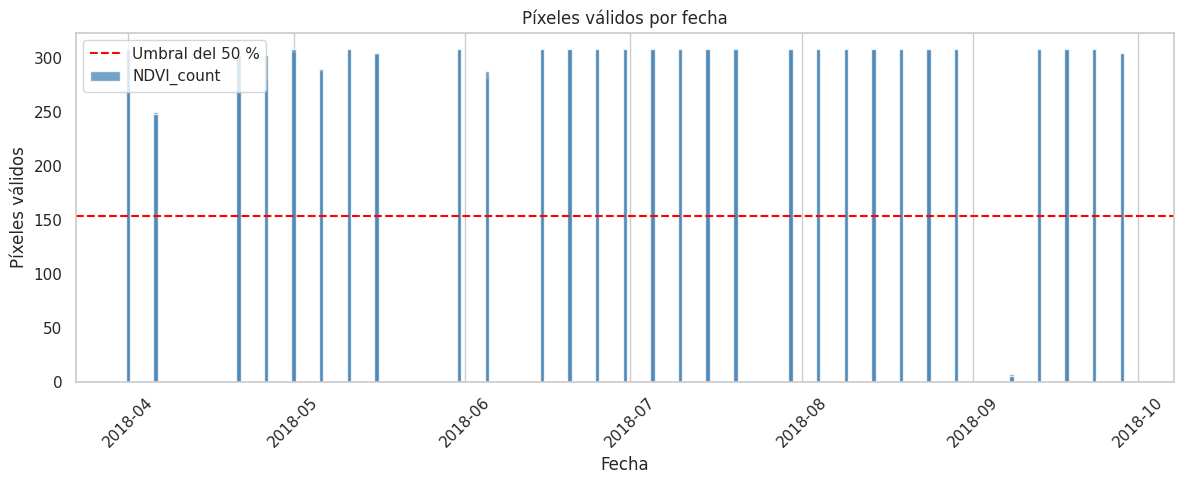

In [ ]:
plt.figure(figsize=(12, 5))

plt.bar(
    df["date"],
    df["NDVI_count"],
    color="steelblue",
    alpha=0.75,
    label="NDVI_count"
)

plt.axhline(
    quality_threshold,
    color="red",
    linestyle="--",
    label="Umbral del 50 %"
)

plt.xlabel("Fecha")
plt.ylabel("Píxeles válidos")
plt.title("Píxeles válidos por fecha")
plt.legend()
plt.grid(axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Representar NVDI

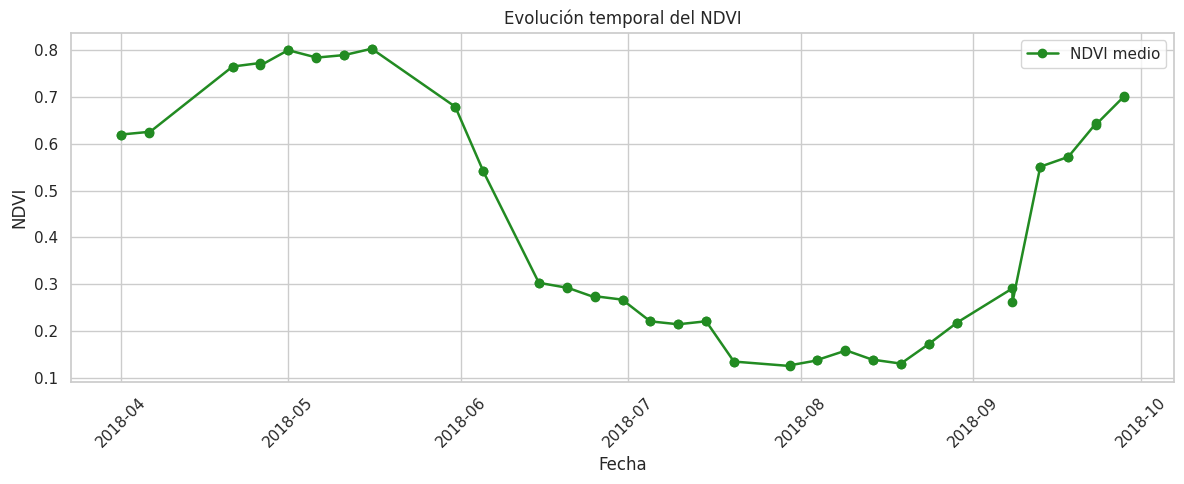

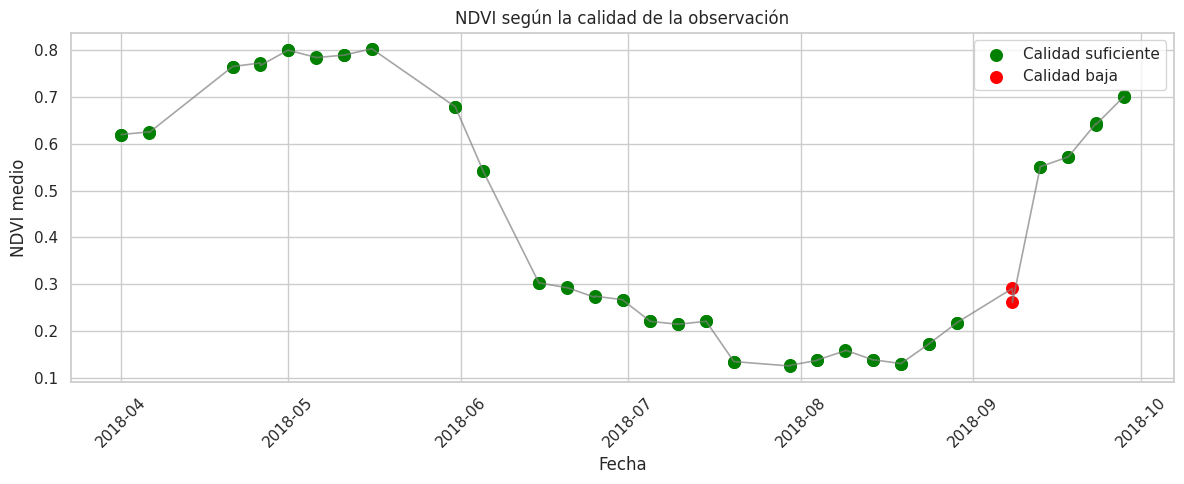

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["NDVI_mean"],
    marker="o",
    linewidth=1.8,
    color="forestgreen",
    label="NDVI medio"
)

plt.xlabel("Fecha")
plt.ylabel("NDVI")
plt.title("Evolución temporal del NDVI")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

valid_dates = df.loc[
    valid_quality,
    "date"
]

invalid_dates = df.loc[
    ~valid_quality,
    "date"
]

plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["NDVI_mean"],
    color="gray",
    linewidth=1.2,
    alpha=0.7
)

plt.scatter(
    valid_dates,
    df.loc[valid_quality, "NDVI_mean"],
    color="green",
    s=70,
    label="Calidad suficiente"
)

plt.scatter(
    invalid_dates,
    df.loc[~valid_quality, "NDVI_mean"],
    color="red",
    s=70,
    label="Calidad baja"
)

plt.xlabel("Fecha")
plt.ylabel("NDVI medio")
plt.title("NDVI según la calidad de la observación")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Representar índices principales

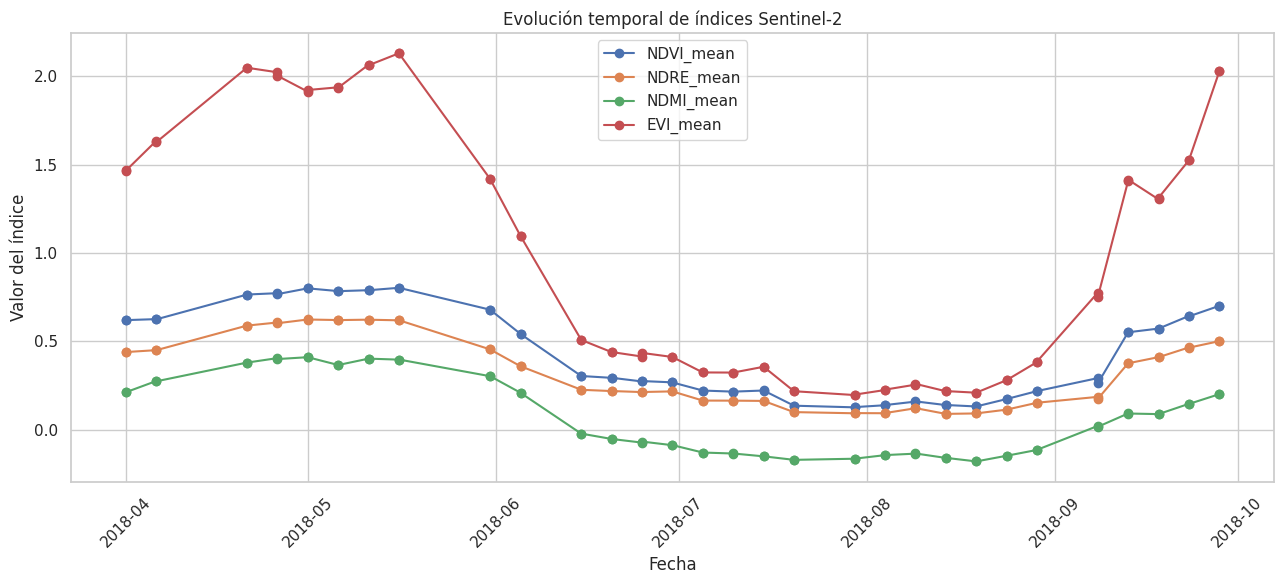

In [ ]:
indices_to_plot = [
    "NDVI_mean",
    "NDRE_mean",
    "NDMI_mean",
    "EVI_mean"
]

available_indices = [
    column
    for column in indices_to_plot
    if column in df.columns
]

plt.figure(figsize=(13, 6))

for column in available_indices:
    plt.plot(
        df["date"],
        df[column],
        marker="o",
        linewidth=1.5,
        label=column
    )

plt.xlabel("Fecha")
plt.ylabel("Valor del índice")
plt.title("Evolución temporal de índices Sentinel-2")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Guardar la primera figura en Google Drive

Carpeta de resultados: /content/drive/MyDrive/Sentinel2_Indices/resultados_exploracion


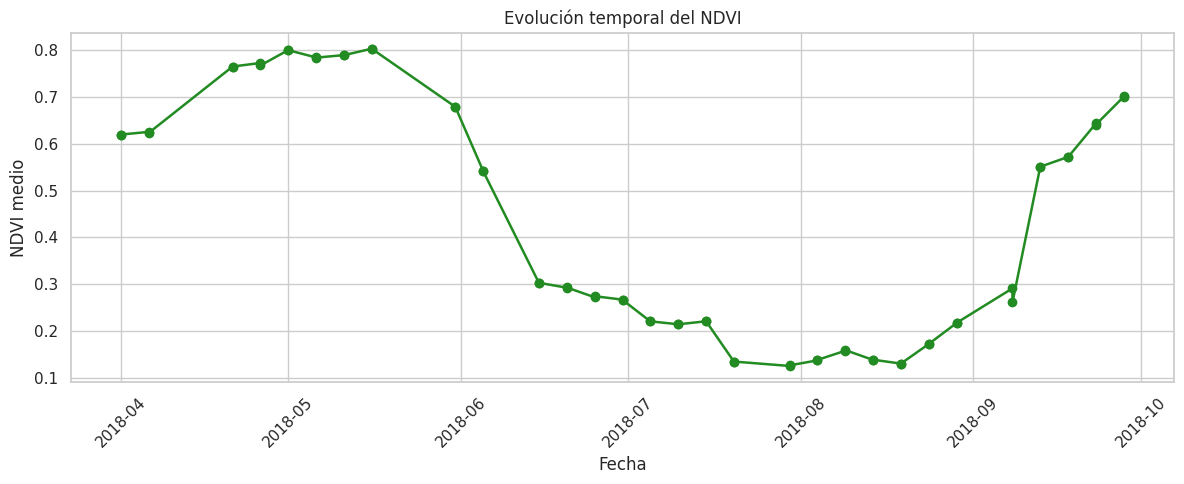

Figura guardada en:
/content/drive/MyDrive/Sentinel2_Indices/resultados_exploracion/evolucion_ndvi.png
Estadísticas guardadas en:
/content/drive/MyDrive/Sentinel2_Indices/resultados_exploracion/estadisticas_descriptivas_indices.csv


In [ ]:
results_path = (
    "/content/drive/MyDrive/"
    "Sentinel2_Indices/"
    "resultados_exploracion"
)

os.makedirs(
    results_path,
    exist_ok=True
)

print("Carpeta de resultados:", results_path)

ndvi_figure_path = os.path.join(
    results_path,
    "evolucion_ndvi.png"
)

plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["NDVI_mean"],
    marker="o",
    linewidth=1.8,
    color="forestgreen"
)

plt.xlabel("Fecha")
plt.ylabel("NDVI medio")
plt.title("Evolución temporal del NDVI")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    ndvi_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print(ndvi_figure_path)

statistics_path = os.path.join(
    results_path,
    "estadisticas_descriptivas_indices.csv"
)

descriptive_statistics.to_csv(
    statistics_path,
    encoding="utf-8-sig"
)

print("Estadísticas guardadas en:")
print(statistics_path)

##Resumen final

In [ ]:
# Asegurar que el DataFrame está ordenado por fecha
df = df.sort_values(
    "date"
).reset_index(drop=True)

# Contar cuántas observaciones existen por fecha
date_counts = (
    df["date"]
    .value_counts()
    .sort_index()
)

# Número de fechas que tienen más de una observación
duplicated_dates = (
    date_counts > 1
).sum()

# Calcular el máximo de NDVI_count
ndvi_count_max = df["NDVI_count"].max()

# Calcular el umbral de calidad del 50 %
quality_threshold = (
    0.5 *
    ndvi_count_max
)

# Identificar las observaciones que superan el umbral
valid_quality = (
    df["NDVI_count"] >= quality_threshold
)

# Crear el resumen
summary = pd.DataFrame({
    "metric": [
        "Número de filas originales",
        "Número de columnas",
        "Número de fechas distintas",
        "Primera fecha",
        "Última fecha",
        "Número de fechas repetidas",
        "Valores nulos en NDVI_mean",
        "NDVI_count máximo",
        "Umbral de calidad",
        "Observaciones con calidad suficiente"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["date"].nunique(),
        df["date"].min(),
        df["date"].max(),
        duplicated_dates,
        df["NDVI_mean"].isna().sum(),
        ndvi_count_max,
        quality_threshold,
        valid_quality.sum()
    ]
})

summary

# Crear la carpeta de resultados si todavía no existe
results_path = (
    "/content/drive/MyDrive/"
    "Sentinel2_Indices/"
    "resultados_exploracion"
)

os.makedirs(
    results_path,
    exist_ok=True
)

# Definir la ruta de salida
summary_path = os.path.join(
    results_path,
    "resumen_exploracion.csv"
)

# Guardar el resumen
summary.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen guardado correctamente en:")
print(summary_path)

Resumen guardado correctamente en:
/content/drive/MyDrive/Sentinel2_Indices/resultados_exploracion/resumen_exploracion.csv


## Conclusiones preliminares

A partir del análisis realizado:

- El CSV contiene observaciones procedentes de imágenes Sentinel-2.
- La serie temporal presenta observaciones en fechas concretas y no
  necesariamente una observación diaria.
- Los índices espectrales permiten analizar la evolución de la vegetación.
- NDVI_count puede utilizarse como indicador aproximado de calidad espacial.
- Las imágenes con pocos píxeles válidos deben estudiarse antes de incorporarlas
  al simulador.
- Sentinel-2 no proporciona directamente la humedad del suelo.
- Será necesario incorporar información meteorológica y un modelo de balance
  hídrico.
- La interpolación temporal, si se utiliza, deberá diferenciar entre valores
  observados y valores estimados.

# Preparación de la serie temporal

Las observaciones de Sentinel-2 no tienen necesariamente una frecuencia diaria.
En esta sección se prepara una serie temporal diaria para utilizarla
posteriormente en el simulador.

Se distinguirán dos tipos de valores:

- Valores observados directamente en fechas con imágenes Sentinel-2.
- Valores estimados mediante interpolación temporal.

La interpolación no crea nuevas observaciones satelitales, sino valores
aproximados entre dos fechas disponibles.

Filas originales: 60
Filas después de la limpieza: 60
Primera fecha: 2018-04-01 00:00:00
Última fecha: 2018-09-28 00:00:00
Fechas con observaciones repetidas:


,count
date,
2018-04-01,2
2018-04-06,2
2018-04-21,2
2018-04-26,2
2018-05-01,2
2018-05-06,2
2018-05-11,2
2018-05-16,2
2018-05-31,2


Columnas de índices seleccionadas:
['BSI_mean', 'EVI_mean', 'GNDVI_mean', 'MNDWI_mean', 'MSI_mean', 'NBR_mean', 'NDMI_mean', 'NDRE2_mean', 'NDRE3_mean', 'NDRE_mean', 'NDVI_mean', 'NDWI_mean', 'NIR_RED_mean', 'RECI_mean', 'SAVI_mean']
La columna NDVI_count está disponible.
Filas después de agrupar por fecha:
30
Máximo NDVI_count: 308.0
Umbral de calidad: 154.0
Fechas antes del filtro: 30
Fechas después del filtro: 29
Primera fecha de la serie diaria: 2018-04-01 00:00:00
Última fecha de la serie diaria: 2018-09-28 00:00:00
Número de filas de la serie diaria: 181
Días observados: 29
Días sin observación: 152
Columnas que se interpolarán:
['BSI_mean', 'EVI_mean', 'GNDVI_mean', 'MNDWI_mean', 'MSI_mean', 'NBR_mean', 'NDMI_mean', 'NDRE2_mean', 'NDRE3_mean', 'NDRE_mean', 'NDVI_mean', 'NDWI_mean', 'NIR_RED_mean', 'RECI_mean', 'SAVI_mean']
Valores nulos restantes en los índices:
BSI_mean        0
EVI_mean        0
GNDVI_mean      0
MNDWI_mean      0
MSI_mean        0
NBR_mean        0
NDMI_mean 

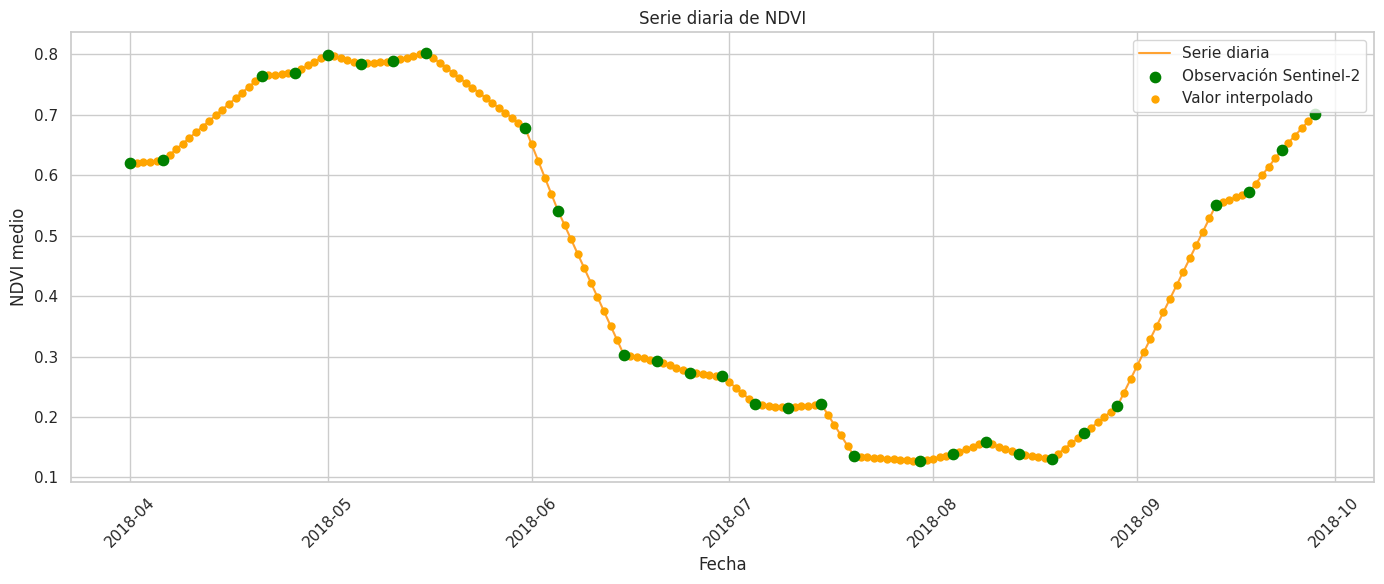

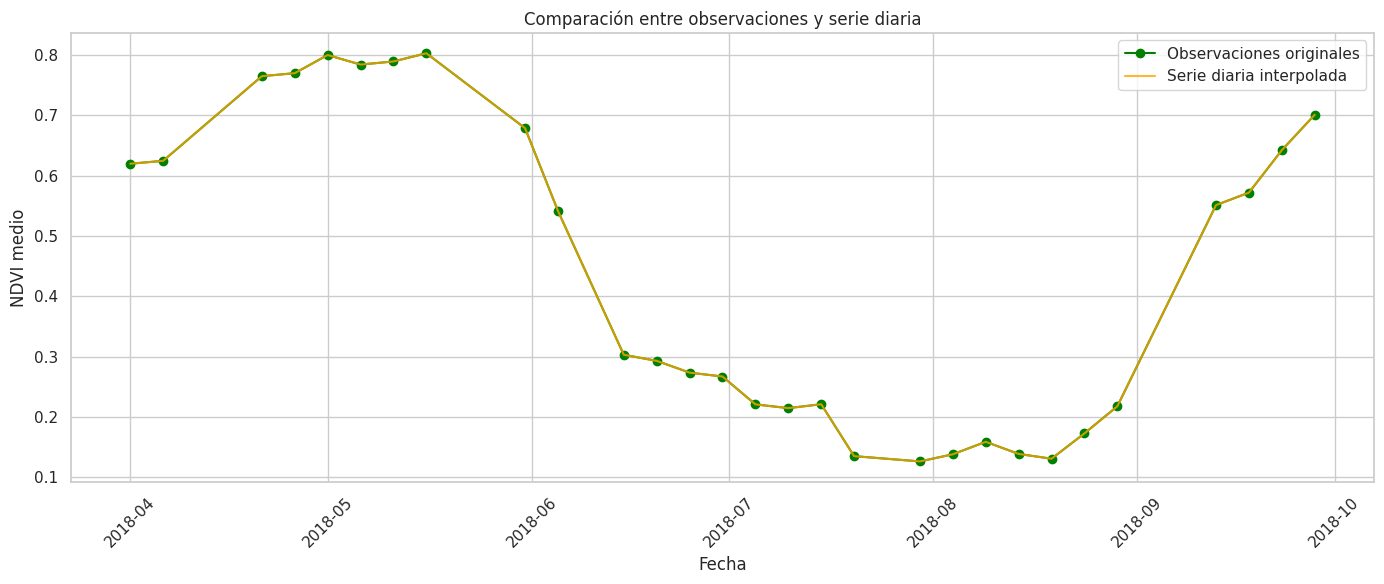

Dimensiones de daily: (181, 19)
Primera fecha: 2018-04-01 00:00:00
Última fecha: 2018-09-28 00:00:00
Días totales: 181
Días observados: 29
Días interpolados: 152
Fechas duplicadas: 0
Serie diaria guardada en:
/content/drive/MyDrive/Sentinel2_Indices/resultados_exploracion/serie_diaria_sentinel2.csv


,metric,value
0,Primera fecha,2018-04-01 00:00:00
1,Última fecha,2018-09-28 00:00:00
2,Número de días,181
3,Días con observación Sentinel-2,29
4,Días interpolados,152
5,Número de índices,15
6,Valores nulos en NDVI_mean,0


Resumen diario guardado en:
/content/drive/MyDrive/Sentinel2_Indices/resultados_exploracion/resumen_serie_diaria.csv


In [ ]:
# Crear una copia para el preprocesamiento
df_clean = df.copy()

# Asegurar el formato de fecha
df_clean["date"] = pd.to_datetime(
    df_clean["date"],
    errors="coerce"
)

# Eliminar filas sin fecha o sin NDVI
df_clean = df_clean.dropna(
    subset=["date", "NDVI_mean"]
)

# Ordenar cronológicamente
df_clean = df_clean.sort_values(
    "date"
).reset_index(drop=True)

print("Filas originales:", len(df))
print("Filas después de la limpieza:", len(df_clean))
print("Primera fecha:", df_clean["date"].min())
print("Última fecha:", df_clean["date"].max())

date_counts_clean = (
    df_clean["date"]
    .value_counts()
    .sort_index()
)

repeated_dates = date_counts_clean[
    date_counts_clean > 1
]

print("Fechas con observaciones repetidas:")
display(repeated_dates)

mean_columns = [
    column
    for column in df_clean.columns
    if column.endswith("_mean")
]

print("Columnas de índices seleccionadas:")
print(mean_columns)

if "NDVI_count" in df_clean.columns:
    print("La columna NDVI_count está disponible.")
else:
    print("ATENCIÓN: no existe NDVI_count.")

columns_for_daily = mean_columns.copy()

if "NDVI_count" in df_clean.columns:
    columns_for_daily.append("NDVI_count")

daily_observed = (
    df_clean
    .groupby("date")[columns_for_daily]
    .mean()
    .sort_index()
)

print("Filas después de agrupar por fecha:")
print(len(daily_observed))

daily_observed.head()

if "NDVI_count" in daily_observed.columns:
    count_max_observed = (
        daily_observed["NDVI_count"].max()
    )

    quality_threshold_observed = (
        0.5 *
        count_max_observed
    )

    quality_mask = (
        daily_observed["NDVI_count"]
        >= quality_threshold_observed
    )

    daily_quality = daily_observed[
        quality_mask
    ].copy()

    print(
        "Máximo NDVI_count:",
        count_max_observed
    )

    print(
        "Umbral de calidad:",
        quality_threshold_observed
    )

    print(
        "Fechas antes del filtro:",
        len(daily_observed)
    )

    print(
        "Fechas después del filtro:",
        len(daily_quality)
    )
else:
    daily_quality = daily_observed.copy()

    print(
        "No se aplica filtro porque NDVI_count no está disponible."
    )

daily = daily_quality.resample("D").asfreq()

print("Primera fecha de la serie diaria:", daily.index.min())
print("Última fecha de la serie diaria:", daily.index.max())
print("Número de filas de la serie diaria:", len(daily))

daily.isna().sum().sort_values(
    ascending=False
).head(20)

daily["observed"] = daily["NDVI_mean"].notna()

print(
    "Días observados:",
    daily["observed"].sum()
)

print(
    "Días sin observación:",
    (~daily["observed"]).sum()
)

daily[["NDVI_mean", "observed"]].head(15)

if "NDVI_count" in daily.columns:
    daily["NDVI_count_observed"] = (
        daily["NDVI_count"]
    )

value_columns = [
    column
    for column in daily.columns
    if column.endswith("_mean")
]

print("Columnas que se interpolarán:")
print(value_columns)

daily[value_columns] = (
    daily[value_columns]
    .interpolate(method="time")
)

remaining_nulls = (
    daily[value_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

remaining_nulls.head(20)

print(
    "Valores nulos restantes en los índices:"
)

print(
    daily[value_columns]
    .isna()
    .sum()
)

first_valid_date = (
    daily["NDVI_mean"]
    .first_valid_index()
)

last_valid_date = (
    daily["NDVI_mean"]
    .last_valid_index()
)

daily = daily.loc[
    first_valid_date:last_valid_date
].copy()

print("Primera fecha final:", daily.index.min())
print("Última fecha final:", daily.index.max())

daily[value_columns].isna().sum()

daily["data_source"] = np.where(
    daily["observed"],
    "sentinel_observed",
    "time_interpolated"
)

daily[
    [
        "NDVI_mean",
        "observed",
        "data_source"
    ]
].head(20)

daily["NDVI_count"] = daily["NDVI_count"].interpolate()

if "NDVI_count" in daily.columns:
    daily = daily.drop(
        columns=["NDVI_count"]
    )

daily = daily.reset_index()
daily.head()

priority_columns = [
    "date",
    "NDVI_mean",
    "NDRE_mean",
    "NDMI_mean",
    "EVI_mean",
    "observed",
    "data_source",
    "NDVI_count_observed"
]

priority_columns = [
    column
    for column in priority_columns
    if column in daily.columns
]

other_columns = [
    column
    for column in daily.columns
    if column not in priority_columns
]

daily = daily[
    priority_columns + other_columns
]

daily.head()

plt.figure(figsize=(14, 6))

plt.plot(
    daily["date"],
    daily["NDVI_mean"],
    color="darkorange",
    linewidth=1.5,
    alpha=0.8,
    label="Serie diaria"
)

observed_mask = daily["observed"]

plt.scatter(
    daily.loc[observed_mask, "date"],
    daily.loc[observed_mask, "NDVI_mean"],
    color="green",
    s=55,
    label="Observación Sentinel-2",
    zorder=3
)

interpolated_mask = ~observed_mask

plt.scatter(
    daily.loc[interpolated_mask, "date"],
    daily.loc[interpolated_mask, "NDVI_mean"],
    color="orange",
    s=25,
    label="Valor interpolado",
    zorder=2
)

plt.xlabel("Fecha")
plt.ylabel("NDVI medio")
plt.title("Serie diaria de NDVI")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

plt.plot(
    daily_quality.index,
    daily_quality["NDVI_mean"],
    "o-",
    color="green",
    label="Observaciones originales"
)

plt.plot(
    daily["date"],
    daily["NDVI_mean"],
    "-",
    color="orange",
    alpha=0.8,
    label="Serie diaria interpolada"
)

plt.xlabel("Fecha")
plt.ylabel("NDVI medio")
plt.title("Comparación entre observaciones y serie diaria")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Dimensiones de daily:", daily.shape)
print("Primera fecha:", daily["date"].min())
print("Última fecha:", daily["date"].max())
print("Días totales:", len(daily))
print("Días observados:", daily["observed"].sum())
print("Días interpolados:", (~daily["observed"]).sum())

print(
    "Fechas duplicadas:",
    daily["date"].duplicated().sum()
)

daily_path = os.path.join(
    results_path,
    "serie_diaria_sentinel2.csv"
)

daily.to_csv(
    daily_path,
    index=False,
    encoding="utf-8-sig"
)

print("Serie diaria guardada en:")
print(daily_path)

daily_summary = pd.DataFrame({
    "metric": [
        "Primera fecha",
        "Última fecha",
        "Número de días",
        "Días con observación Sentinel-2",
        "Días interpolados",
        "Número de índices",
        "Valores nulos en NDVI_mean"
    ],
    "value": [
        daily["date"].min(),
        daily["date"].max(),
        len(daily),
        daily["observed"].sum(),
        (~daily["observed"]).sum(),
        len(value_columns),
        daily["NDVI_mean"].isna().sum()
    ]
})

display(daily_summary)

daily_summary_path = os.path.join(
    results_path,
    "resumen_serie_diaria.csv"
)

daily_summary.to_csv(
    daily_summary_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen diario guardado en:")
print(daily_summary_path)

## Conclusiones de la preparación temporal

- Se ha creado una única observación por fecha.
- Se han eliminado las filas que no tenían fecha o `NDVI_mean`.
- Se ha aplicado un filtro orientativo basado en `NDVI_count`.
- Se ha generado una frecuencia diaria entre la primera y la última observación
  válida.
- Los índices espectrales se han interpolado temporalmente.
- Se ha añadido la columna `observed` para distinguir observaciones reales de
  valores interpolados.
- La columna `data_source` identifica el origen de cada valor.
- `NDVI_count` no se ha interpolado porque representa una medida de calidad
  asociada a imágenes reales.
- La serie diaria es una preparación para el simulador, no una colección de
  nuevas observaciones Sentinel-2.